# SIMPlex Breast Cancer — extra exploration

Starts from the deposited cross-patient Harmony-integrated object (`SIMPlex_breast_allSamples.rds`). No upstream merge or integration re-run required.


In [3]:
# DATA_ROOT, HDF5 library, palettes — single source of truth for paths.
source(here::here("config.R"))

In [4]:
# HDF5 library is loaded by config.R
library(semla)
library(tibble)
library(Seurat)
options(Seurat.object.assay.version = "v5")
library(patchwork)
library(singlet)
library(RcppML)
library(ggplot2)
library(dplyr)
library(tidyr)
library(viridis)
library(pheatmap)
library(cowplot)
library(corrplot)
library(RColorBrewer)
library(heatmap3)
library(harmony)
library(gridExtra)
library(paletteer)
library(Matrix)

Warning message:
“replacing previous import ‘S4Arrays::makeNindexFromArrayViewport’ by ‘DelayedArray::makeNindexFromArrayViewport’ when loading ‘SummarizedExperiment’”

Attaching package: ‘singlet’


The following object is masked from ‘package:Seurat’:

    ProjectData


Loading required package: viridisLite


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


corrplot 0.95 loaded

Loading required package: Rcpp


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




### Settings


In [5]:
rootObj <- paste0(SN_RDS, "/breast_cancer/cross_patient/")
wd <- paste0(FIGS_ROOT, "/breast_cancer/extra_exploration/")
dir.create(wd, recursive = TRUE, showWarnings = FALSE)

colsCelltype <- c("#EAE29CFF", "#6CC382FF", "#E99F69FF", "#CF597EFF", "#EAC17AFF", "#29AD8EFF", "#B2D387FF", "#E4796DFF", "#089392FF")
colsSample <- paletteer_c("grDevices::Dark 3", 10)
colsSubtype <- c("#6EA9B0", "#B1A6D1", "#E18A96")
colsMalignancy <- c("#84D7E1", "#6ABE8C", "#FF95A8")
colsAssays <- c("#6A5ACD", "#FFA500", "#20B2AA")

### Load data

`SIMPlex_breast_allSamples.rds` is ~8 GB. Expect several minutes to load and substantial RAM. Use the **R (simplex renv)** kernel.


In [6]:
int.all <- readRDS(file.path(rootObj, "SIMPlex_breast_allSamples.rds"))

### Object summary


In [7]:
int.all

An object of class Seurat 
38023 features across 71418 samples within 2 assays 
Active assay: RNA (19022 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: SCT
 6 dimensional reductions calculated: pca, umap, harmony, pca_subpop, umap_subpop, harmony_subpop

In [8]:
Assays(int.all)
Reductions(int.all)

[1] "RNA" "SCT"

[1] "pca"            "umap"           "harmony"        "pca_subpop"    
[5] "umap_subpop"    "harmony_subpop"

In [9]:
ncol(int.all)
nrow(int.all)

[1] 71418

[1] 19022

In [10]:
table(int.all$sample)


patient1_55um patient2_55um patient4_55um   patient4_HD patient5_55um 
        10495          8401          3049          7751          7678 
  patient5_HD patient6_55um patient7_55um patient8_55um patient9_55um 
         6709          7229          5653          4990          9463 

In [11]:
table(int.all$population)


  Adipocytes      B-cells         CAFs  Endothelial   Epithelial      Myeloid 
         401         1872         9778         3137        36977         7927 
Plasmablasts          PVL      T-cells 
        1979         1248         8099 

In [12]:
head(colnames(int.all@meta.data))

[1] "orig.ident"      "seurat_clusters" "nCount_RNA"      "nFeature_RNA"   
[5] "sample"          "percent.mt"

## iCAF subpopulation LR gene sanity check
Validation of interesting genes from LR analysis

In [16]:
# Patient 4 only (same as CellTalker circos)
pat4_sn <- subset(int.all, subset = sample == "patient4_55um")
pat4_sn$subpopulation <- gsub("_", "-", pat4_sn$subpopulation)
Idents(pat4_sn) <- "subpopulation"
DefaultAssay(pat4_sn) <- "RNA"

icaf_pops <- sort(unique(pat4_sn$subpopulation[grepl("^iCAF-", pat4_sn$subpopulation)]))
mcaf_pops <- c("mCAF-classical", "mCAF-remodeling", "mCAF-plastic", "mCAF-patient4-specific")
caf_pops <- c(icaf_pops, mcaf_pops)
immune_pops <- c("pDCs", "Plasma-cells", "B-cells-activated", "B/T-mixed-patient4")
receptor_pops <- c(immune_pops, "Cancer-Transitional-pat4")
ligand_genes <- c("CXCL12", "C3", "THBS2")
receptor_genes <- c("CXCR4", "C3AR1", "CD47")

icaf_pops

[1] "iCAF-classical"        "iCAF-lipid-associated" "iCAF-secretory"

Warning message:
“Removing 583 cells missing data for vars requested”


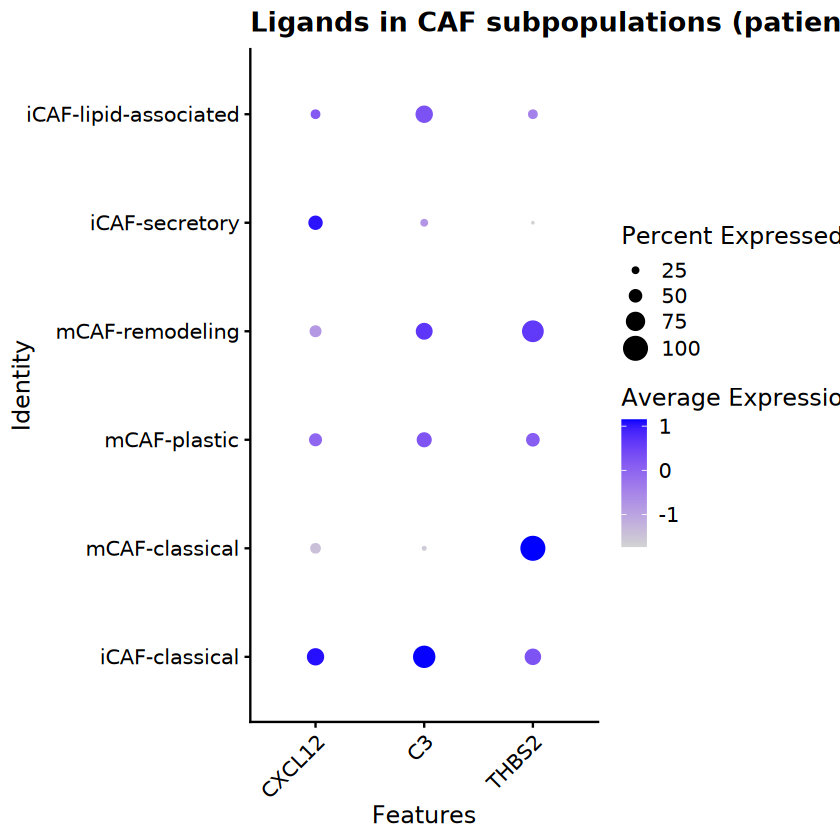

In [17]:
pat4_caf <- subset(pat4_sn, subset = subpopulation %in% caf_pops)

DotPlot(pat4_caf, features = ligand_genes) +
  RotatedAxis() +
  ggtitle("Ligands in CAF subpopulations (patient 4)")

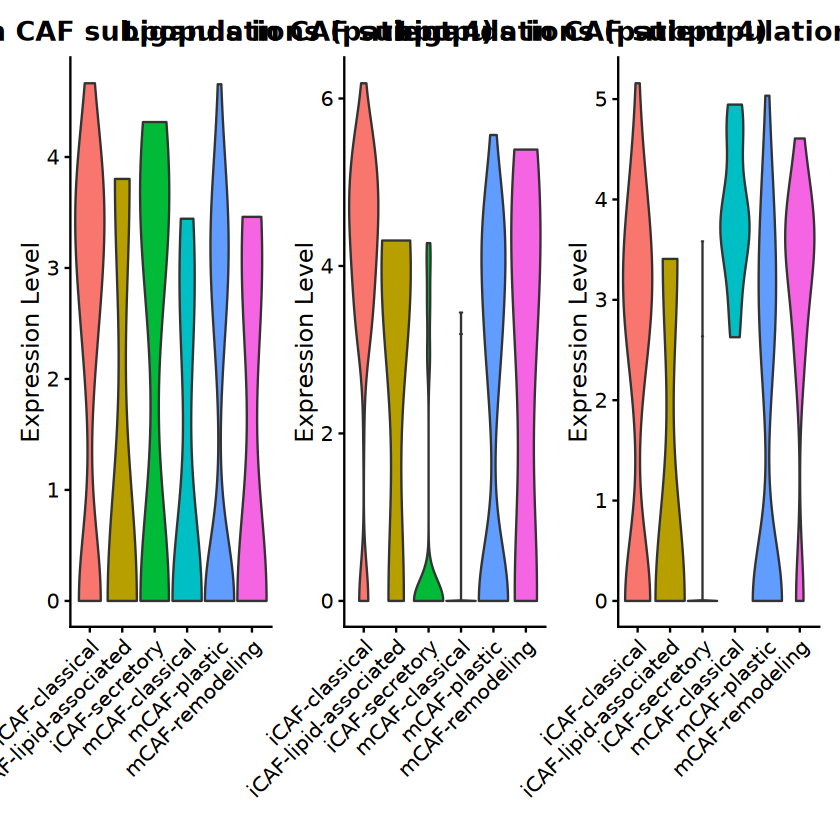

In [18]:
VlnPlot(
  pat4_caf,
  features = ligand_genes,
  group.by = "subpopulation",
  pt.size = 0,
  ncol = length(ligand_genes)
) & xlab("") & ggtitle("Ligands in CAF subpopulations (patient 4)")

Warning message:
“Removing 583 cells missing data for vars requested”


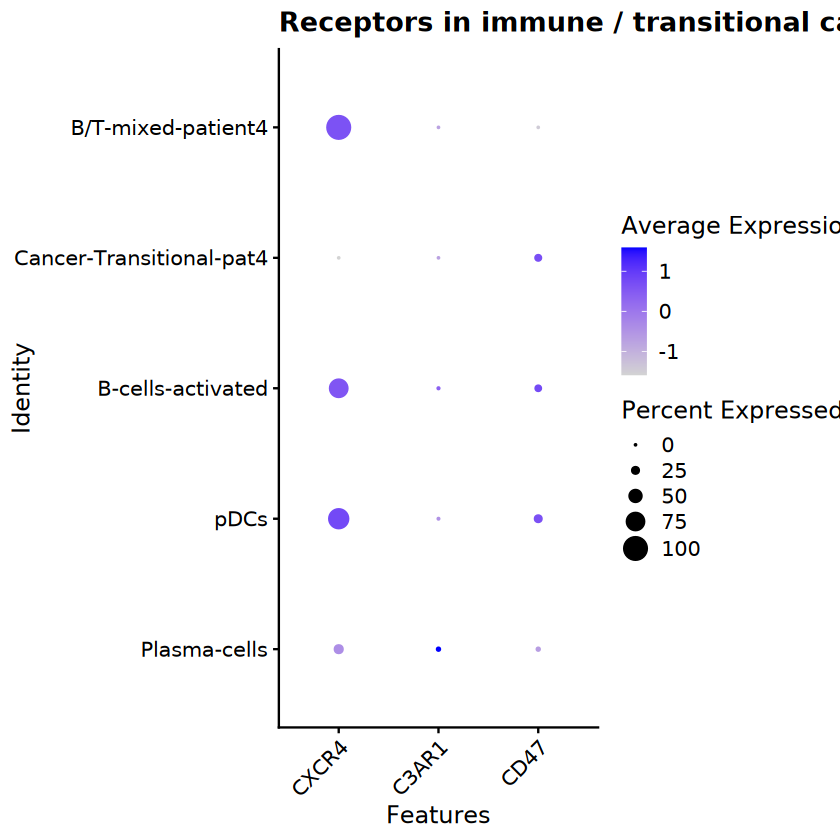

In [19]:
pat4_receiver <- subset(pat4_sn, subset = subpopulation %in% receptor_pops)

DotPlot(pat4_receiver, features = receptor_genes) +
  RotatedAxis() +
  ggtitle("Receptors in immune / transitional cancer (patient 4)")

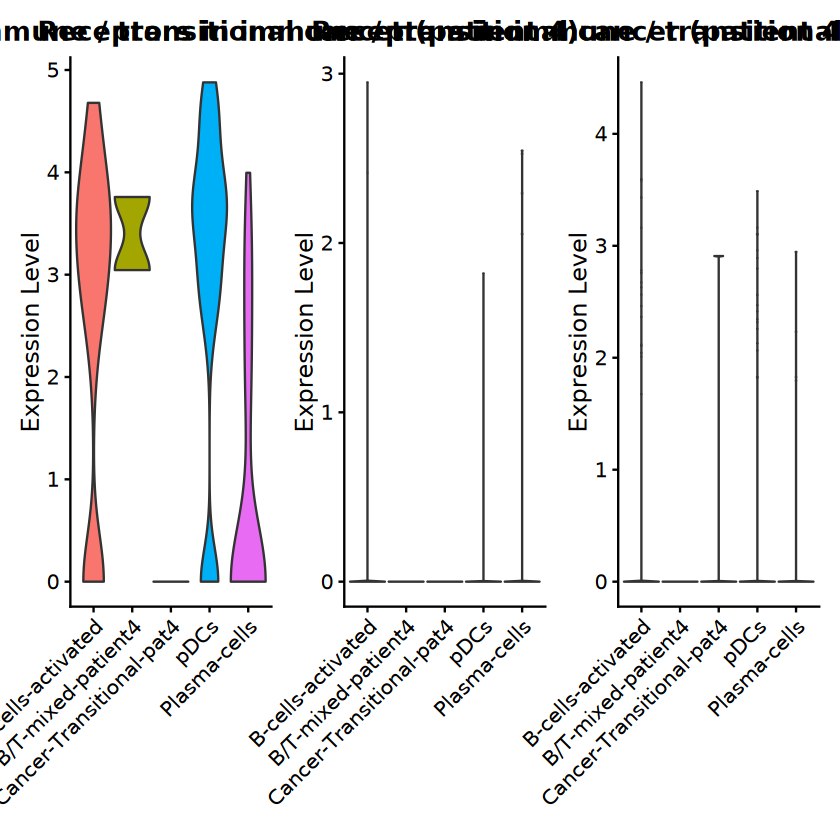

In [20]:
VlnPlot(
  pat4_receiver,
  features = receptor_genes,
  group.by = "subpopulation",
  pt.size = 0,
  ncol = length(receptor_genes)
) & xlab("") & ggtitle("Receptors in immune / transitional cancer (patient 4)")